# Fine-tuning SegFormer для сегментации автомобилей

**Цель:** обучить модель **SegFormer** с **менее 1 млн. обучаемых параметров** для задачи semantic segmentation и добиться качества **IoU ≥ 0.92** на тестовой выборке. Размер изображений для обучений и теста должен быть **<= 384х384**. (см пункт "4. Проверки")

Для выполнения используется **уникальный сплит** датасета [Carvana Image Masking Challenge](https://www.kaggle.com/c/carvana-image-masking-challenge)

Работаем **только с частью `train`** датасета
## Система оценки

### Подход к решению (макс 5 баллов)

*Промежуточные оценки выставляются по широте экспериментов*

**1 балл**

- обучена одна модель SegFormer
- стандартный pipeline
- стандартные transforms / loss / optimizer

---

**3 балла**

- рассмотрено **минимум 2 решения**

например:

- разные модели (`SegFormer-B0`, `SegFormer-B1`) и/или веса
- или разная стратегия finetuning (заморозка encoder целиком / частично / добавление слоев)

или

- проведено **2–3 эксперимента оптимизации**

например:

- scheduler
- аугментации
- разные функции потерь

---

**5 баллов**

- минимум **2 архитектурных решения**
- **+ минимум 2 эксперимента оптимизации**

например:

- BCE vs Dice loss
- разные стратегии resize / crop
- scheduler
- аугментации

---

### Качество решения vs cтоимость (макс 5 баллов)

Метрика: **Intersection over Union (IoU)**

**+1 балл**

если

```
IoU ≥ 0.87
```

**+2 балла**

если

```
IoU ≥ 0.92
```

**+2 балла**:

уложились с качеством в **10 эпох** обучения

---

**Можно получить дополнительный +1 балл в качестве поощрения от ревьюера**

за:
- вспомогательную визуалиацию, поиск новых закономерностей
- оригинальные архитектурные решения

## 1. Формирование уникального сплита

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import random
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import albumentations as A


def set_seed_to_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)


DATE_OF_BIRTH: int = 17
MONTH_OF_BIRTH: int = 4
HEIGHT = 181
LASTNAME = "Kalitsov"

seed = (DATE_OF_BIRTH + MONTH_OF_BIRTH) * (ord(LASTNAME[0])%(HEIGHT%10))

set_seed_to_all(seed)

In [2]:
from sklearn.model_selection import train_test_split


images = sorted(os.listdir("/kaggle/input/datasets/amirankalitsov/dataset/carvana-image-masking-challenge/train"))
df = pd.DataFrame({"image": images})
df["car_id"] = df["image"].apply(lambda x: x.split("_")[0])
car_ids = df["car_id"].unique()
subset_cars = random.sample(list(car_ids), 100)
my_data = df[df["car_id"].isin(subset_cars)]

train_ids, temp_ids = train_test_split(
    subset_cars,
    test_size=0.3,
    random_state=seed
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.5,
    random_state=seed
)

train_df = df[df["car_id"].isin(train_ids)]
val_df = df[df["car_id"].isin(val_ids)]
test_df = df[df["car_id"].isin(test_ids)]

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 1120
Val: 240
Test: 240


In [3]:
len(my_data)

1600

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2. Подготовка данных
Реализовать самим

In [5]:
from PIL import Image
class CarvanaDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_dir: str = "/kaggle/input/datasets/amirankalitsov/dataset/carvana-image-masking-challenge/train",
        mask_dir: str = "/kaggle/input/datasets/amirankalitsov/dataset/carvana-image-masking-challenge/train_masks",
        transform: transforms.Compose | A.Compose | None = None,
    ):
        self.df = df
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def num_classes(self):
        return len(self.target_idx_to_car_id)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image'].replace('.jpg', '')
        
        img_path  = f"{self.image_dir}/{img_name}.jpg"
        mask_path = f"{self.mask_dir}/{img_name}_mask.gif"
        
        # Загружаем изображение и маску
        image = np.array(Image.open(img_path).convert("RGB"))
        mask  = np.array(Image.open(mask_path).convert("L"), dtype=np.float32) # Luminance (яркость) 
        
        # Бинаризуем маску: 0.0 или 1.0
        mask = (mask == 255.).astype(np.float32)
        
        if self.transform is not None:
            # Albumentations
            if isinstance(self.transform, A.Compose):
                augmented = self.transform(image=image, mask=mask)
                image = augmented["image"]  # уже тензор, если ToTensorV2 в пайплайне
                mask  = augmented["mask"]
                mask = mask.unsqueeze(0)
            # torchvision transforms
            elif isinstance(self.transform, transforms.Compose):
                image = self.transform(Image.fromarray(image))
                mask  = transforms.ToTensor()(mask)
        else:
            # Базовая конвертация в тензор без трансформаций
            image = transforms.ToTensor()(image)
            mask  = torch.tensor(mask).unsqueeze(0)  # [1, H, W]
        
        return image, mask

In [6]:
transform = A.Compose([
    A.Resize(384, 384),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)),
    A.ToTensorV2(),
])

train_ds = CarvanaDataset(train_df, transform=transform)
val_ds = CarvanaDataset(val_df, transform=transform)
test_ds = CarvanaDataset(test_df, transform=transform)

train_loader = DataLoader(train_ds, batch_size=32, num_workers=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, num_workers=4, shuffle=False)

## 3. Подбор архитектуры и обучение
Самим подобрать Segformer (и версию, и претрейн веса), решить какую часть обучать, настроить гиперпараметры, выбрать лосс и обучить сеть  
Рекомендую брать из трансформерс и искать хороший претрейн  
```
from transformers import SegformerForSemanticSegmentation
```

In [41]:
from transformers import SegformerForSemanticSegmentation
import torch.nn.functional as F
from tqdm import tqdm
from typing import List, Optional, Callable, Any
import matplotlib.pyplot as plt
from torchmetrics import JaccardIndex
from IPython.display import clear_output

In [42]:
def plot_losses(train_losses: List[float], train_scores: List[float], val_losses: List[float], val_scores: List[float]):

    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_scores) + 1), train_scores, label='train')
    axs[1].plot(range(1, len(val_scores) + 1), val_scores, label='val')
    axs[1].set_ylabel('IoU metric')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()


def training_epoch(model: nn.Module, 
                   optimizer: torch.optim.Optimizer, 
                   criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None,
                   loader: DataLoader, 
                   scheduler: Optional[Any],
                   tqdm_desc: str):

    device = next(model.parameters()).device
    total_loss  = 0.0
    # Jaccard Index == IoU == Jaccard Similarity Coefficient - это типчик, который придумал
    metric = JaccardIndex(task="binary").to(device)
    metric.reset()

    model.train()
    for images, masks in tqdm(loader, desc=tqdm_desc):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        labels = masks.squeeze(1).long()  # (B, 384, 384)  long

        output = model(pixel_values=images, labels=labels)
        # модель внутри сама ресайзит маску до 96x96
        # и считает CrossEntropyLoss

        logits_upsampled = F.interpolate(
                output.logits,
                size=(384, 384),
                mode="bilinear"
            )
        
        pred = logits_upsampled.argmax(dim=1)   # (B, 384, 384)
        target = masks.squeeze(1).long()  

        metric.update(pred, target)

        if criterion is not None:
            loss = criterion(logits_upsampled, target)
        else:
            loss = output.loss    # скаляр
        # logits = output.logits  # (B, 2, 96, 96)

        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        

    total_loss /= len(loader.dataset)
    return total_loss, metric.compute().item()


@torch.no_grad()
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None = None
) -> float:

    device = next(model.parameters()).device
    total_loss = 0.0

    model.eval()
    metric = JaccardIndex(task="binary").to(device)
    metric.reset()
    for images, masks in tqdm(dataloader, desc="Validation"):
        images = images.to(device)
        masks = masks.to(device)
        labels = masks.squeeze(1).long()  # (B, 384, 384)  long

        output = model(pixel_values=images, labels=labels)

        logits_upsampled = F.interpolate(
                output.logits,
                size=(384, 384),
                mode="bilinear"
            )
        
        pred = logits_upsampled.argmax(dim=1)   # (B, 384, 384)
        target = masks.squeeze(1).long()

        if criterion is not None:
            loss = criterion(logits_upsampled, target)
        else:
            loss = output.loss 
        
        total_loss += loss.item()

        metric.update(pred, target)

    return total_loss / len(dataloader.dataset), metric.compute().item()


def train(model: nn.Module, 
          optimizer: torch.optim.Optimizer,
          train_loader: DataLoader, 
          val_loader: DataLoader, 
          num_epochs: int,
          criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] | None = None,
          scheduler: Optional[Any] = None):

    train_losses, train_scores, val_losses, val_scores = [], [], [], []

    for epoch in range(1, num_epochs + 1):
        train_loss, train_score = training_epoch(
            model, 
            optimizer, 
            criterion, 
            train_loader,
            scheduler,
            tqdm_desc=f'Training {epoch}/{num_epochs}',
        )
        val_loss, val_score = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        train_scores.append(train_score)
        val_losses.append(val_loss)
        val_scores.append(val_score)
        plot_losses(train_losses, train_scores, val_losses, val_scores)
        print(f"Epoch {epoch} results:")
        print(f"train: loss={train_loss:.3f} score={train_score:.3f}")
        print(f"validation: loss={val_loss:.3f} score={val_score:.3f}")

In [9]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model.to(device)

# заморозим всё
for param in model.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model.decode_head.parameters():
    param.requires_grad = True 

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

In [10]:
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 395266


In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

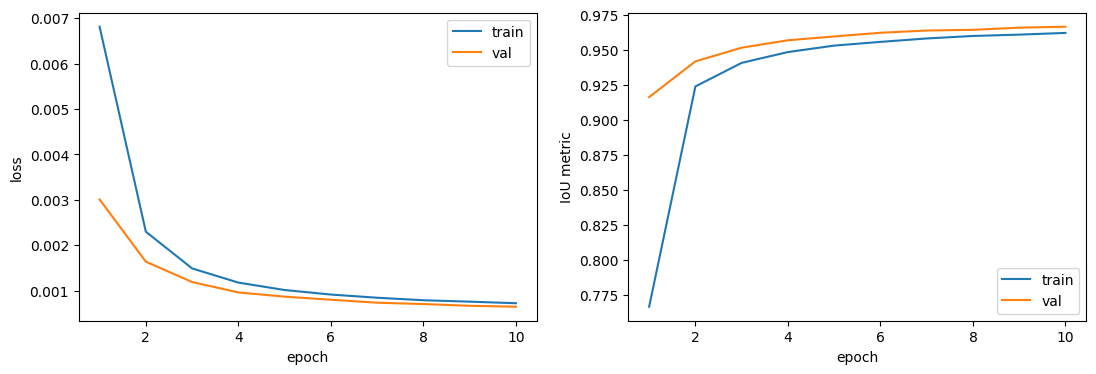

Epoch 10 results:
train: loss=0.001 score=0.962
validation: loss=0.001 score=0.967


In [12]:
train(model=model, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10)

Ну трэшхолды уже пробили, что не может не радовать. Попробую визуализировать предсказания модели.

In [13]:
def visualize_predictions(model, dataset, device, num_images=4, threshold=0.5):
    model.eval()
    
    fig, axes = plt.subplots(num_images, 3, figsize=(12, num_images * 4))
    # 3 колонки: оригинал | маска (ground truth) | предсказание
    
    axes[0, 0].set_title("Оригинал",      fontsize=14)
    axes[0, 1].set_title("Ground Truth",  fontsize=14)
    axes[0, 2].set_title("Предсказание",  fontsize=14)
    
    # Берём случайные индексы
    indices = np.random.choice(len(dataset), num_images, replace=False)
    
    with torch.no_grad():
        for row, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Добавляем batch dimension
            image_batch = image.unsqueeze(0).to(device)  # (1, 3, H, W)
            
            # Предсказание
            logits = model(pixel_values=image_batch).logits  # (1, 2, H/4, W/4)
            
            # Upsample до исходного размера
            H, W = image.shape[1], image.shape[2]
            logits_upsampled = F.interpolate(
                logits,
                size=(H, W),
                mode="bilinear",
                align_corners=False
            )  # (1, 2, H, W)
            
            # Бинарная маска предсказания
            pred_mask = logits_upsampled.argmax(dim=1)  # (1, H, W)
            pred_mask = pred_mask.squeeze(0).cpu().numpy()  # (H, W)
            
            # Подготовка оригинала для отображения
            # Денормализация ImageNet
            mean = np.array([0.485, 0.456, 0.406])
            std  = np.array([0.229, 0.224, 0.225])
            
            image_np = image.permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
            image_np = (image_np * std + mean).clip(0, 1) # обрезаем всё, что вылезло
            
            # Ground truth маска
            mask_np = mask.squeeze(0).cpu().numpy()  # (H, W)
            
            # Отображение
            axes[row, 0].imshow(image_np)
            axes[row, 0].axis("off")
            
            axes[row, 1].imshow(mask_np, cmap="gray")
            axes[row, 1].axis("off")
            
            axes[row, 2].imshow(pred_mask, cmap="gray")
            axes[row, 2].axis("off")
            
            # IoU для каждого изображения
            intersection = (pred_mask * mask_np).sum()
            union        = (pred_mask + mask_np).clip(0, 1).sum()
            iou          = intersection / (union + 1e-6)
            axes[row, 2].set_title(f"IoU: {iou:.3f}", fontsize=12)
    
    plt.tight_layout()
    plt.show()

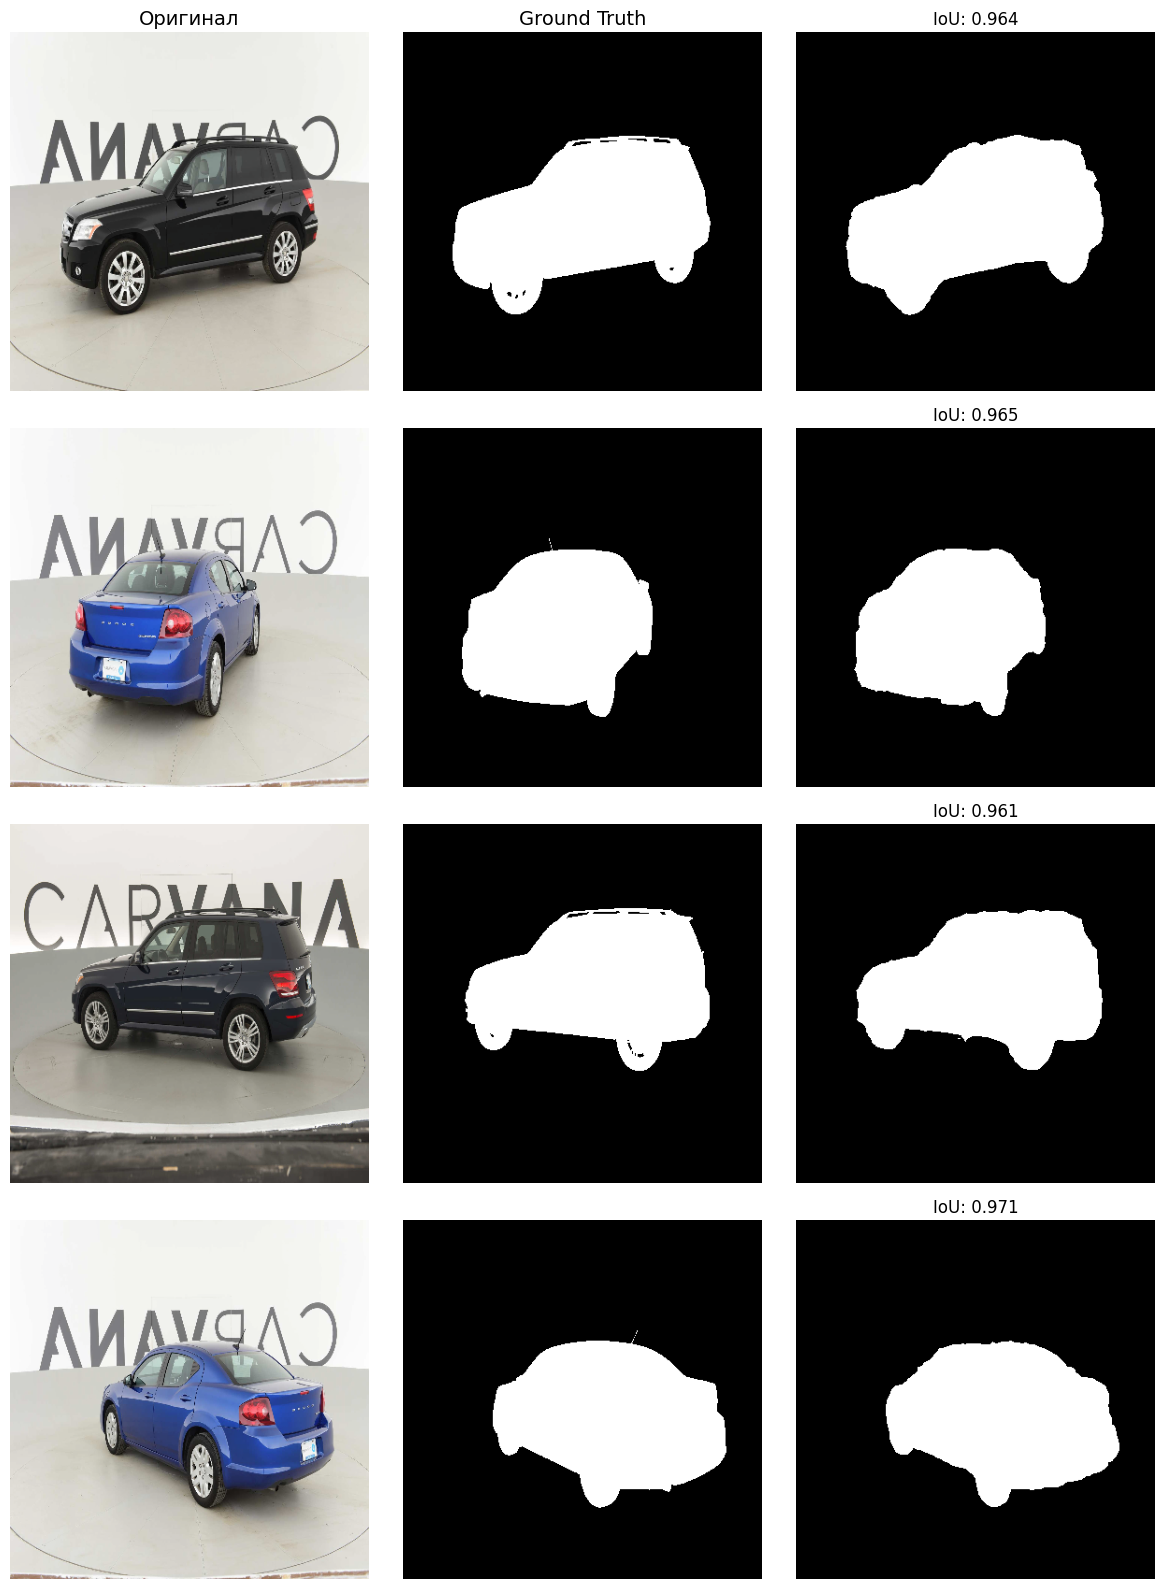

In [14]:
visualize_predictions(
    model      = model,
    dataset    = val_ds,
    device     = device,
    num_images = 4
)

Попробуем обучить модель побольше:

In [19]:
model_bigger = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b1",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_bigger.to(device)

# заморозим всё
for param in model_bigger.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_bigger.decode_head.parameters():
    param.requires_grad = True 

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b1
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

In [20]:
trainable_params = sum(
    p.numel() for p in model_bigger.parameters()
    if p.requires_grad
)
print(f"Trainable parameters: {trainable_params}")

Trainable parameters: 526338


In [21]:
optimizer = torch.optim.Adam(model_bigger.parameters(), lr=3e-4)

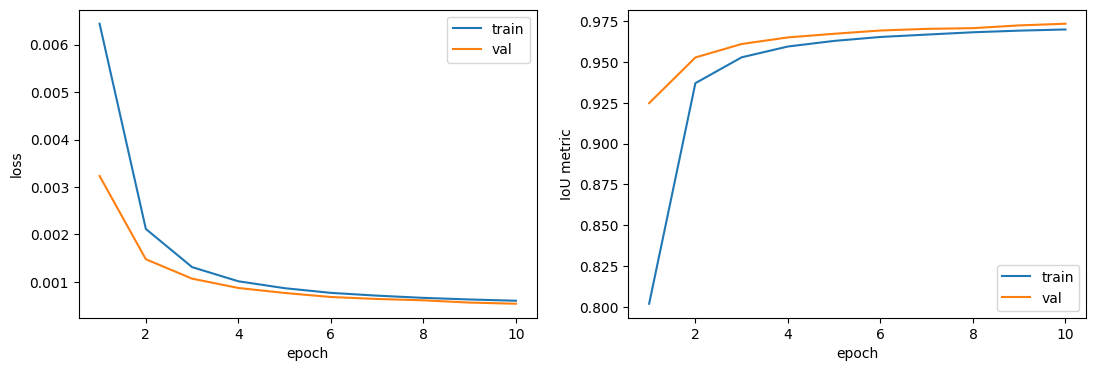

Epoch 10 results:
train: loss=0.001 score=0.970
validation: loss=0.001 score=0.973


In [22]:
train(model=model_bigger, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10)

Большая моделька обучилась получше.

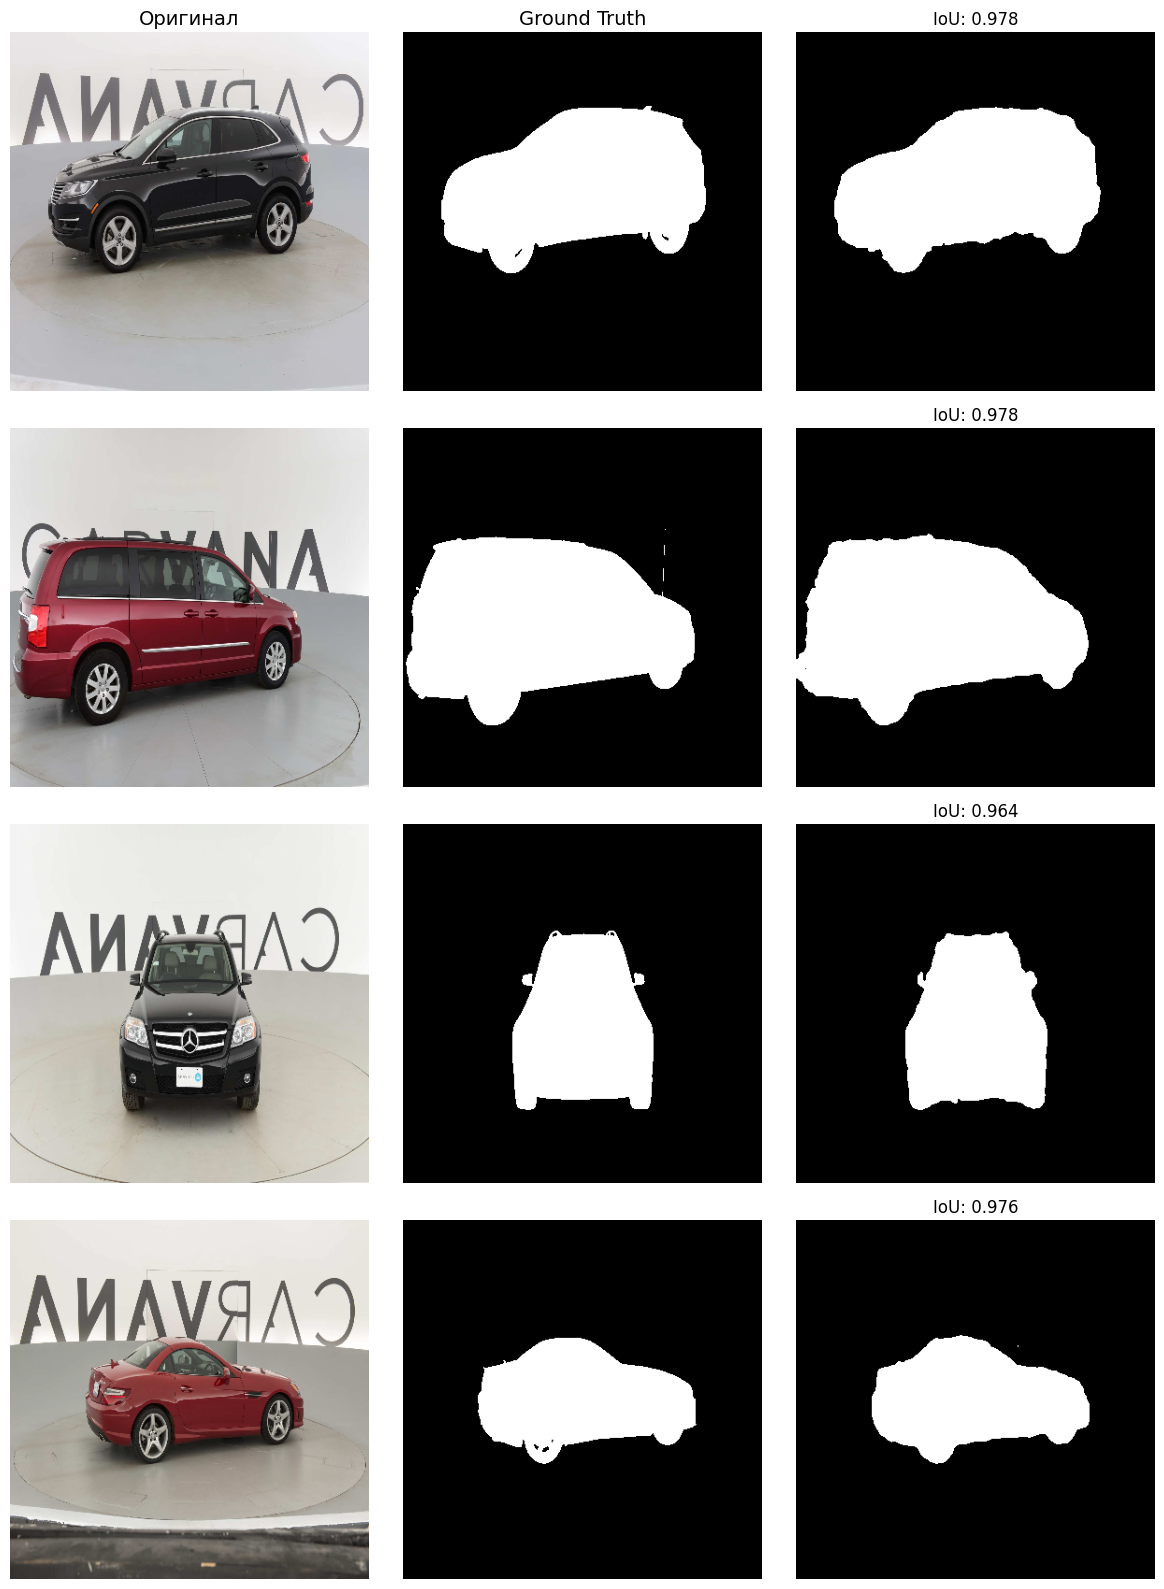

In [30]:
visualize_predictions(
    model      = model_bigger,
    dataset    = val_ds,
    device     = device,
    num_images = 4
)

Сейчас у нас модель обучается на кроссэнтропии с двумя классами, так как она зависит от обоих логитов, это не тоже самое, что BCE. Попробую обучить отдельно на BCE, DICE и их комбинации модель и сравить результаты.

In [34]:
def bce_loss(logits, target):
    """
    logits: (B, 2, H, W)  — сырые выходы модели (до sigmoid)
    target: (B, 1, H, W) или (B, H, W) — float32, значения 0.0 или 1.0
    """
    pred   = logits[:, 1:, :, :]                                        # (B, 1, H, W)
    target = target.unsqueeze(1) if target.ndim == 3 else target        # (B, 1, H, W)
    target = target.float()
    return F.binary_cross_entropy_with_logits(pred, target)


def dice_loss(logits, target, eps=1e-6):
    """
    logits: (B, 2, H, W)  — сырые выходы модели (до sigmoid)
    target: (B, 1, H, W) или (B, H, W) — float32, значения 0.0 или 1.0
    """
    pred   = torch.sigmoid(logits[:, 1:, :, :])                         # (B, 1, H, W)
    target = target.unsqueeze(1) if target.ndim == 3 else target        # (B, 1, H, W)
    target = target.float()

    intersection = (pred * target).sum(dim=(1, 2, 3))
    union        = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))

    dice = (2 * intersection + eps) / (union + eps)
    return 1 - dice.mean()



def bce_dice_loss(logits, target, bce_weight=0.5, dice_weight=0.5):
    """
    logits:      (B, 1, H, W)
    target:      (B, 1, H, W)
    bce_weight:  вес BCE в итоговом loss
    dice_weight: вес Dice в итоговом loss
    """
    bce  = bce_loss(logits, target)
    dice = dice_loss(logits, target)

    return bce_weight * bce + dice_weight * dice

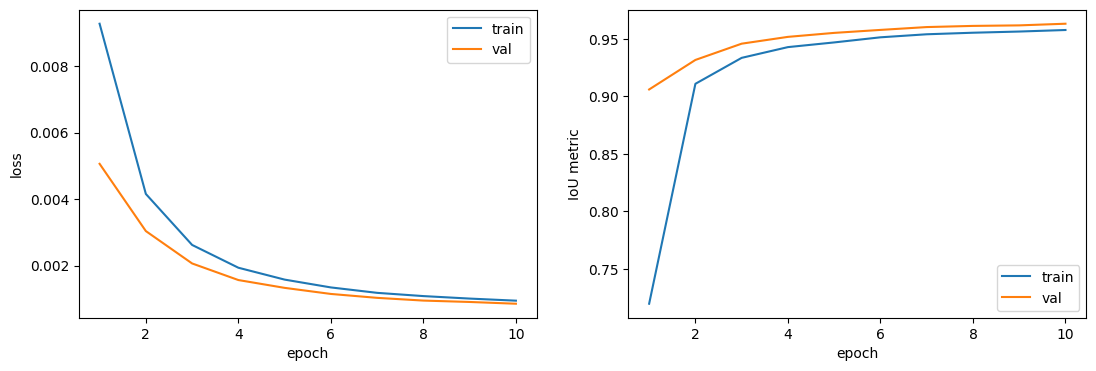

Epoch 10 results:
train: loss=0.001 score=0.958
validation: loss=0.001 score=0.963


In [35]:
model_bce = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_bce.to(device)

# заморозим всё
for param in model_bce.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_bce.decode_head.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(model_bce.parameters(), lr=3e-4)

train(model=model_bce, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10, 
      criterion=bce_loss)

Ну, чуть хуже кросс энтропии от двух классов

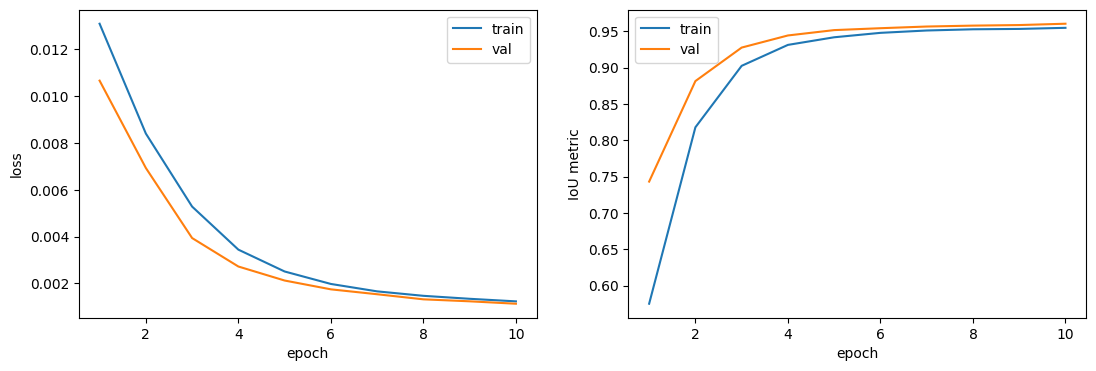

Epoch 10 results:
train: loss=0.001 score=0.955
validation: loss=0.001 score=0.960


In [36]:
model_dice = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_dice.to(device)

# заморозим всё
for param in model_dice.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_dice.decode_head.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(model_dice.parameters(), lr=3e-4)

train(model=model_dice, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10, 
      criterion=dice_loss)

Качество не переплюнуло CE с двумя классами. Тут совсем другая функция потерь, по этому интересно глянуть визуализацию предсказаний

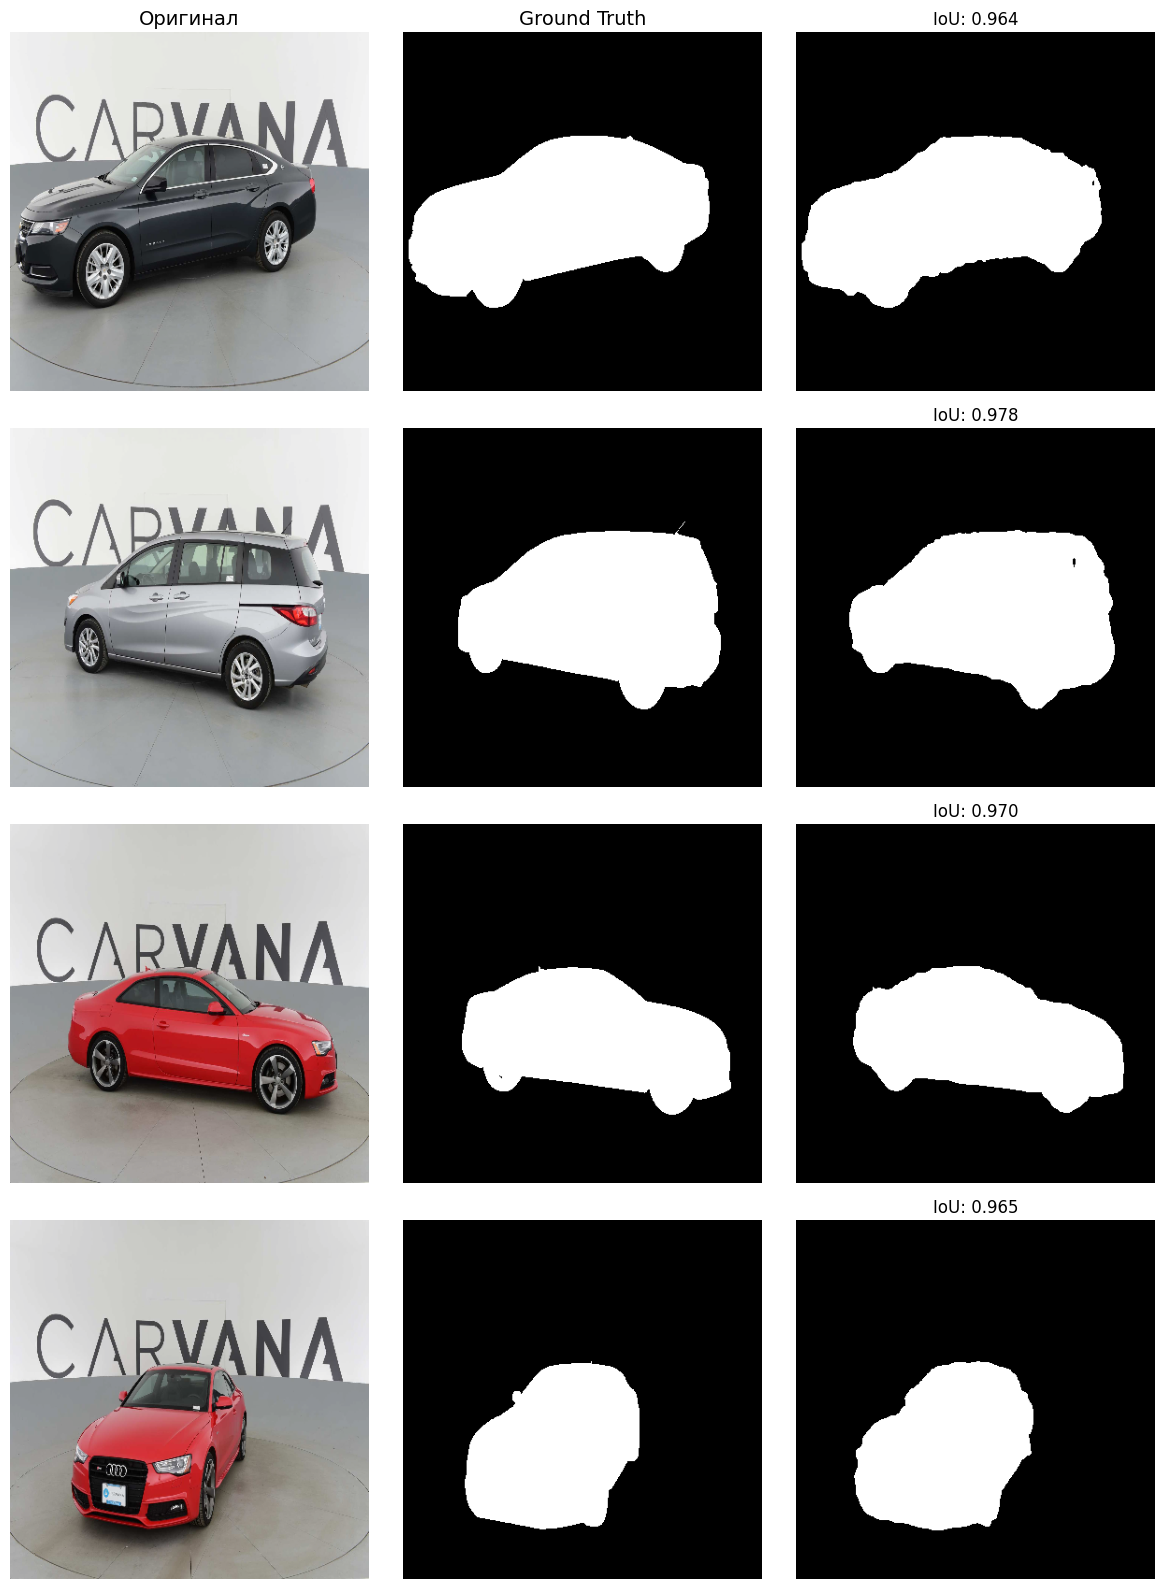

In [43]:
visualize_predictions(
    model      = model_dice,
    dataset    = val_ds,
    device     = device,
    num_images = 4
)

Сильных визуальных отличий я не вижу.

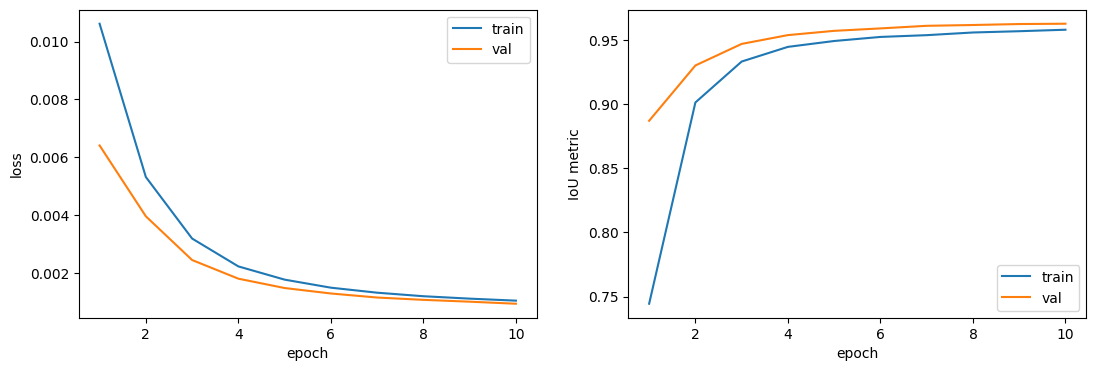

Epoch 10 results:
train: loss=0.001 score=0.958
validation: loss=0.001 score=0.963


In [44]:
model_bce_dice = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_bce_dice.to(device)

# заморозим всё
for param in model_bce_dice.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_bce_dice.decode_head.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(model_bce_dice.parameters(), lr=3e-4)

train(model=model_bce_dice, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10, 
      criterion=lambda logits, target: bce_dice_loss(logits, target, bce_weight=0.5, dice_weight=0.5))

Опять же, чуть хуже базовой имплементации (в самом трансформере) с кросс энтропией по двум классам.

попробую добавить schedulers

In [45]:
from torch.optim.lr_scheduler import OneCycleLR

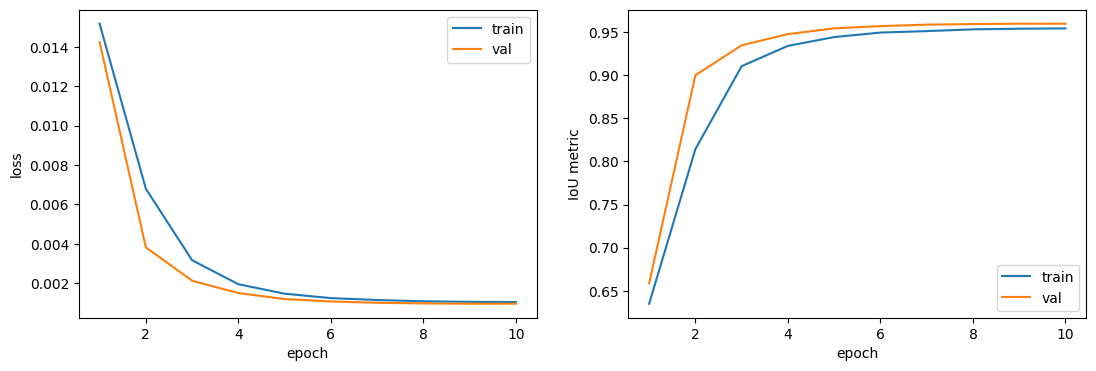

Epoch 10 results:
train: loss=0.001 score=0.954
validation: loss=0.001 score=0.959


In [47]:
 model_with_scheduler = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_with_scheduler.to(device)

# заморозим всё
for param in model_with_scheduler.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_with_scheduler.decode_head.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(model_with_scheduler.parameters(), lr=3e-4)


scheduler = OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=10,
    steps_per_epoch=len(train_loader),  # шаг каждый батч!
    pct_start=0.3,      # 30% времени на warmup
    anneal_strategy="cos"
)

train(model=model_with_scheduler, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10, 
      criterion=None,
      scheduler=scheduler)

что то тоже не дотянуло... каждый раз проблема этого чёртого сильного бейзлайна...

Попробую аугментации

In [49]:
train_transform = A.Compose([
    A.Resize(384, 384),

    # --- Геометрические (применяются и к маске) ---
    A.HorizontalFlip(p=0.5),              # машины симметричны
    A.ShiftScaleRotate(                   # сдвиг, масштаб, поворот
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=15,
        p=0.5
    ),
    A.RandomCrop(                         # случайный кроп
        height=320,
        width=320,
        p=0.3
    ),
    A.Resize(384, 384),                   # возвращаем размер после кропа

    # --- Цветовые (только изображение) ---
    A.ColorJitter(                        # яркость, контраст, насыщенность
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),
    A.GaussNoise(p=0.3),                  # шум
    A.GaussianBlur(blur_limit=3, p=0.2),  # размытие

    # --- Нормализация и конвертация ---
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    A.ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(384, 384),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    A.ToTensorV2(),
])

train_ds = CarvanaDataset(train_df, transform=train_transform)
val_ds = CarvanaDataset(val_df, transform=val_transform)
test_ds = CarvanaDataset(test_df, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=32, num_workers=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, num_workers=4, shuffle=False)

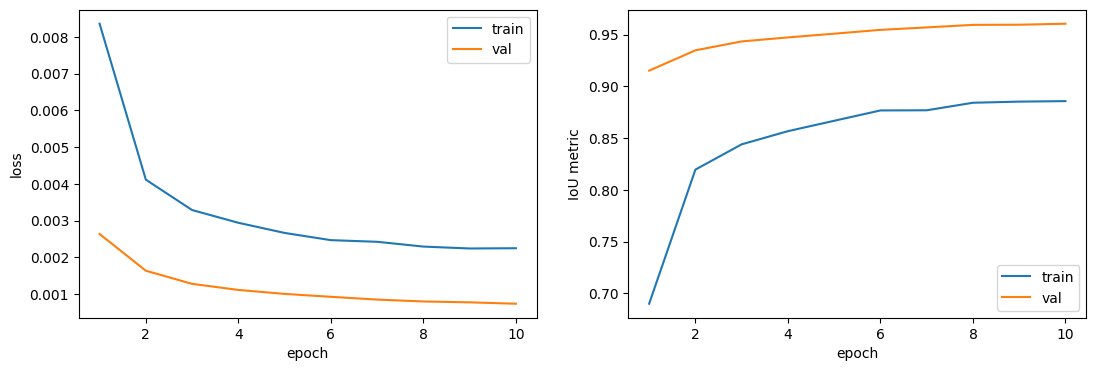

Epoch 10 results:
train: loss=0.002 score=0.886
validation: loss=0.001 score=0.960


In [51]:
 model_with_augmentation = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=2, # классы: есть машина или нет
    ignore_mismatched_sizes=True
)

model_with_augmentation.to(device)

# заморозим всё
for param in model_with_augmentation.segformer.parameters():
    param.requires_grad = False

# разморозим только голову
for param in model_with_augmentation.decode_head.parameters():
    param.requires_grad = True 

optimizer = torch.optim.Adam(model_with_augmentation.parameters(), lr=3e-4)


train(model=model_with_augmentation, 
      optimizer=optimizer,
      train_loader=train_loader, 
      val_loader=val_loader, 
      num_epochs=10, 
      criterion=None,
      scheduler=None)

Чуть хуже, но оно и ясно, они усложняют обучение в короткосрочной перспективе, но при этом помогают чуть дольше повышать качество по ходу обучению (перспективы улучшений в долгосрочном обучении).

## 4. Проверки

In [52]:
# проверка на обучаемые параметры
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Trainable params:", trainable_params)
assert trainable_params < 1_000_000

# провкрка на размеры
for images, masks in test_loader:
    assert images[0].shape[0] <= 384 and images[0].shape[1] <= 384


# проверка качества
_, iou = evaluate(model, test_loader)

if iou > 0.85:
    print("Добились IoU > 0.87")

if iou > 0.92: # тут поправил, было > 0.9
    print("Добились IoU > 0.92")

print("IoU:", iou)

Trainable params: 395266


Validation: 100%|██████████| 8/8 [00:06<00:00,  1.28it/s]

Добились IoU > 0.87
Добились IoU > 0.92
IoU: 0.9665963649749756
